# Example C: Scatter Plot with Axis Histograms

This example features code to generate the following figure:

![example_c](../img/example_c.png)

First we include a cell to import the packages we'll be using:

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

Here we define the data we'd like to plot:

In [21]:
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)

x = penguins['bill_length_mm']
y = penguins['bill_depth_mm']

Calling `plt.subplots()` allows us to separate the figure space and plotted axes into two separate objects (`fig` and `ax`, respectively). This is useful for when multiple plots (`ax` objects) need to be displayed on a single figure (`fig` object). In this example, we use the ax object to show one scatter plot on the figure using `ax.scatter()`.

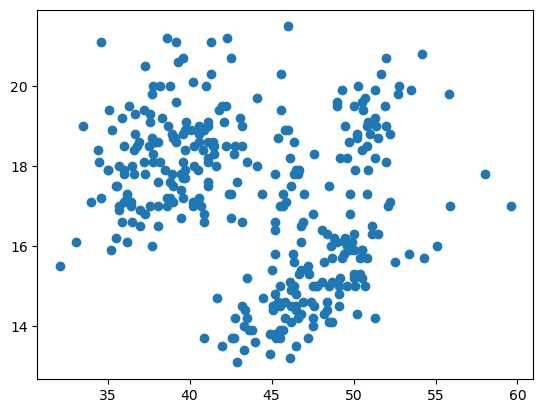

In [22]:
fig, ax = plt.subplots()
scatter = ax.scatter(x, y)

Let's now make full use of `plt.subplots()` by defining one figure (`'fig`) with two Axes objects (`ax1` and `ax2`) arranged as a 1 by 2 matrix. This allows us to display different types of plots on each `ax` object. We can generate the scatter plot on `ax1` and a y-axis histogram on `ax2`.

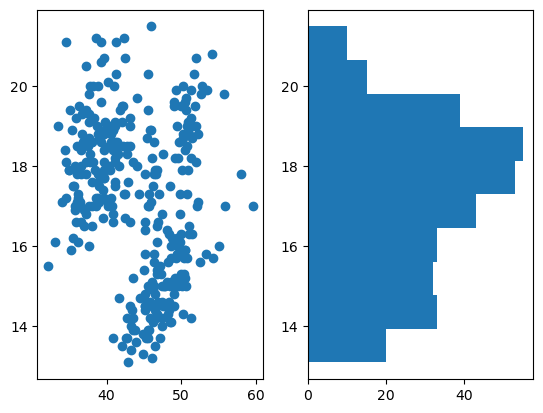

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2) # fig, (tuple_of_Axes_objs) = plt.subplots(n_rows, n_cols)

scatter = ax1.scatter(x, y)
histy = ax2.hist(y, orientation='horizontal')

`plt.subplots()` works well for a continuous *n x m* matrix of plots, but if we want to define a custom plotting configuration on our figure, `plt.subplot_mosaic()` can offer a more intuitive way to specify the layout of each plot.

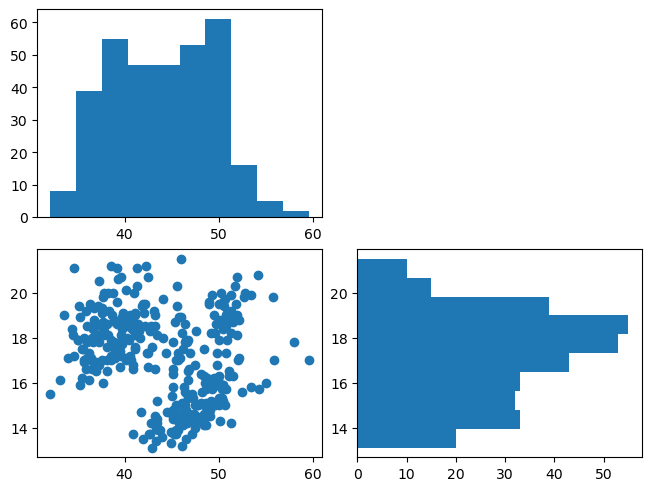

In [ ]:
fig, axs = plt.subplot_mosaic([['histx', '.'],          # Instead of (row, col), here we
                               ['scatter', 'histy']],   # input our own 2X2 matrix of named 
                               layout='constrained')    # plots in our desired orientation

# For the central scatter plot:
scatter = axs['scatter'].scatter(x, y)

# For the top histogram:
histx = axs['histx'].hist(x)

# For the left histogram:
histy = axs['histy'].hist(y, orientation='horizontal')

By default, all plots are scaled equally. We can change this by specifying the `figsize` argument and tuning the size of each plot relative to the other with the `width_ratios` and `height_ratios` arguments.

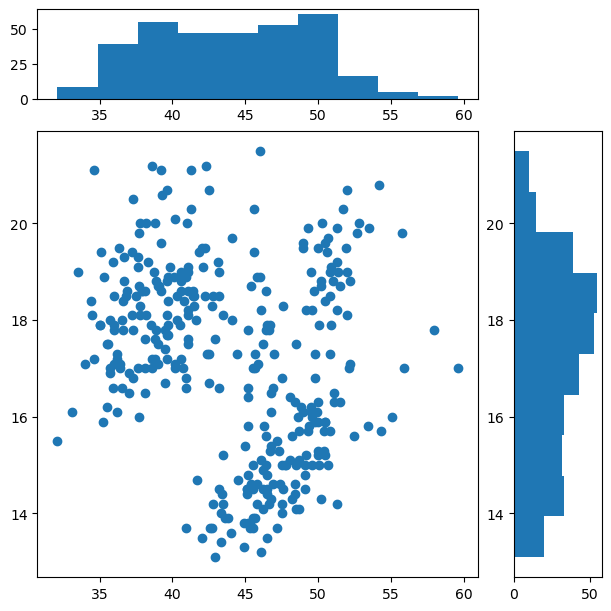

In [ ]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                               figsize=(6, 6),
                               width_ratios=(5, 1),
                               height_ratios=(1, 5),
                               layout='constrained')

# For the central scatter plot:
scatter = axs['scatter'].scatter(x, y)

# For the top histogram:
histx = axs['histx'].hist(x)

# For the left histogram:
histy = axs['histy'].hist(y, orientation='horizontal')

Now we can add some refinements to our plot. Each Axes object can be edited independently to add labels, set x and y ticks, and remove plot spines. Additionally, we can change the number of histogram bins via the `bins` argument within `ax.hist()`.

[]

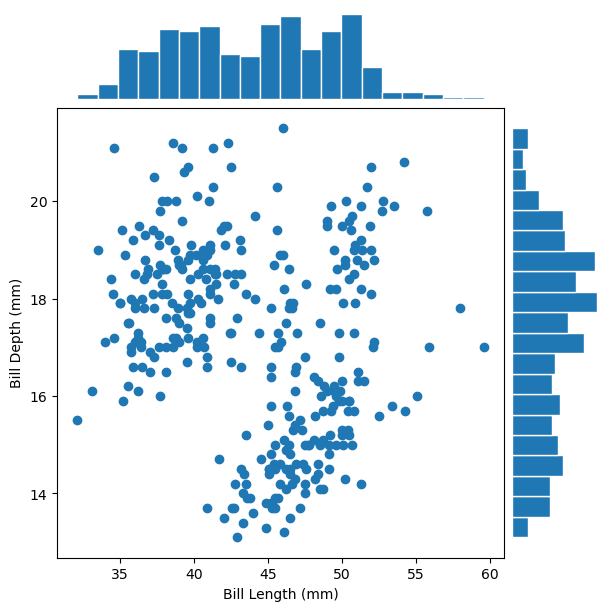

In [38]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                               figsize=(6, 6),
                               width_ratios=(5, 1),
                               height_ratios=(1, 5),
                               layout='constrained')

# For the central scatter plot:
scatter = axs['scatter'].scatter(x, y)
axs['scatter'].xaxis.set_label_text('Bill Length (mm)')
axs['scatter'].yaxis.set_label_text('Bill Depth (mm)')

# For the top histogram:
histx = axs['histx'].hist(x, bins=20,
                          edgecolor='white')
axs['histx'].set_frame_on(False)
axs['histx'].set_xticks([])
axs['histx'].set_yticks([])

# For the left histogram:
histy = axs['histy'].hist(y, bins=20,
                          orientation='horizontal', edgecolor='white')
axs['histy'].set_frame_on(False)
axs['histy'].set_xticks([])
axs['histy'].set_yticks([])

Thus far, we've explored a joint scatter-histogram plot for a single set of data. Sometimes it can be useful to show such a plot for multiple sets of data simultaneously to compare distributions across sets. This is possible with `matplotlib`, but the code required to do so can become tedious to work with:

[]

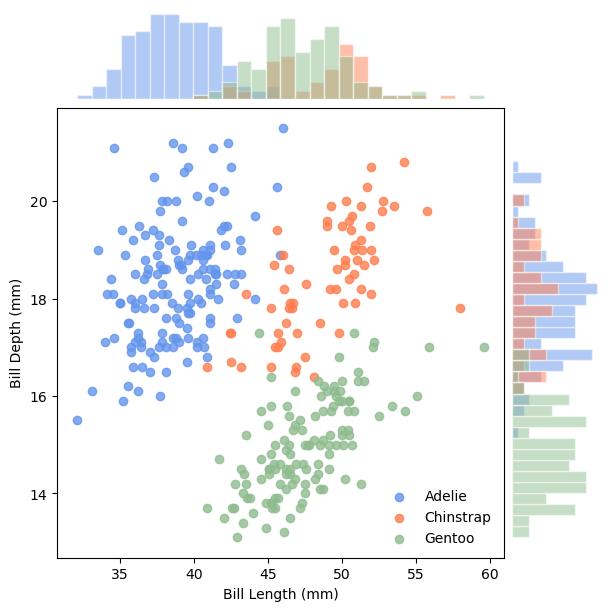

In [ ]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                               figsize=(6, 6),
                               width_ratios=(5, 1),
                               height_ratios=(1, 5),
                               layout='constrained')

x_bin_width = 1.0
x_bins = np.arange(np.min(penguins['bill_length_mm']), np.max(penguins['bill_length_mm'])+1, x_bin_width)

y_bin_width = 0.25
y_bins = np.arange(np.min(penguins['bill_depth_mm']), np.max(penguins['bill_depth_mm'])+1, y_bin_width)

colors = {
    'Adelie': 'cornflowerblue',
    'Chinstrap': 'coral',
    'Gentoo': 'darkseagreen'
}

cmap = penguins['species'].map(colors)

# For each subset of data separated by species:
for species, color in colors.items():
    d = penguins[penguins['species'] == species]

    axs['scatter'].scatter(
        d['bill_length_mm'],
        d['bill_depth_mm'],
        color=color,
        alpha=0.8,
        label=species
    )

    axs['histx'].hist(
        d['bill_length_mm'],
        bins=x_bins,
        color=color,
        edgecolor='white',
        alpha=0.5
    )

    axs['histy'].hist(
        d['bill_depth_mm'],
        bins=y_bins,
        color=color,
        edgecolor='white',
        alpha=0.5,
        orientation='horizontal'
    )

# For the central scatter plot:
axs['scatter'].xaxis.set_label_text('Bill Length (mm)')
axs['scatter'].yaxis.set_label_text('Bill Depth (mm)')
axs['scatter'].legend(frameon=False, loc='lower right')

# For the top histogram:
axs['histx'].set_frame_on(False)
axs['histx'].set_xticks([])
axs['histx'].set_yticks([])

# For the left histogram:
axs['histy'].set_frame_on(False)
axs['histy'].set_xticks([])
axs['histy'].set_yticks([])

In this case, it may be more efficient to use the `seaborn` package which performs much of this work for you via the `sns.jointplot()` method:

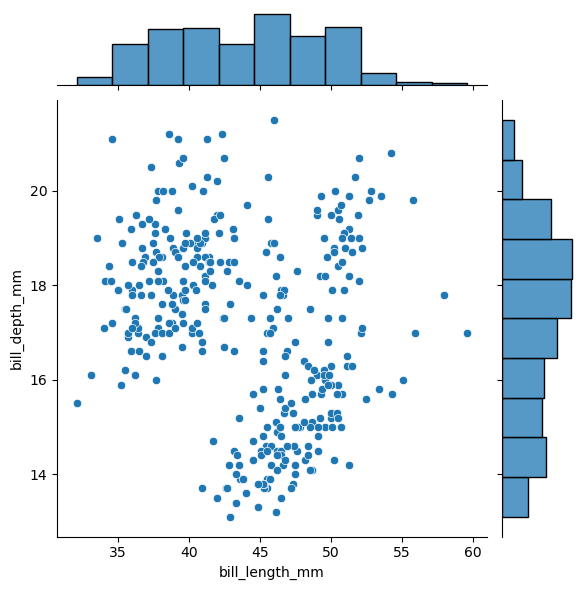

In [19]:
import seaborn as sns

penguins = sns.load_dataset('penguins')

sns.jointplot(data=penguins,
              x='bill_length_mm',
              y='bill_depth_mm')

Plotting the distribution of separate datasets is also very easy with `seaborn`, but **customizing specific details of a seaborn plot may be more difficult and often requires additional matplotlib code.**

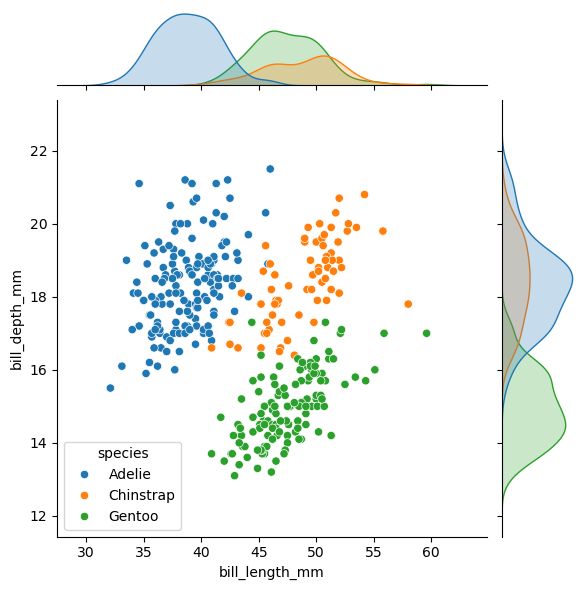

In [28]:
import seaborn as sns

penguins = sns.load_dataset('penguins')

sns.jointplot(data=penguins,
              x='bill_length_mm',
              y='bill_depth_mm',
              hue='species')

- Example from [Matplotlib Gallery](https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_hist.html)
- Modified with inspiration from [Seaborn Jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html)
- Data from [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) dataset